# Verify variants — filtered (`hvg5000`) vs non-filtered (`all_genes`)

A re-runnable audit of the preprocessing outputs and the PCA-vs-scGPT comparison inputs:

1. Gene-count flow (`convert` HVG → `scgpt` OOV-drop)
2. Why scGPT drops genes (`id_in_vocab`)
3. Cell alignment across files
4. What `.X` holds, and where `X_pca` / `X_scGPT` come from
5. `hvg5000` vs `all_genes` gene sets
6. Cross-variant embedding similarity (filtered vs non-filtered `X_scGPT`)
7. **UMAP — PCA vs scGPT, filtered vs non-filtered** (colored by cancer type + paclitaxel viability)

See `docs/steps/02-preprocessing-and-embeddings.md` for the narrative.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp

DATA_ROOT = Path('/Users/selin/Desktop/OncoTox/data/processed/scRNAseq_SCP542')
VARIANTS = ['hvg5000', 'all_genes']
FILES = {
    'convert':    'SCP542_CCLE.h5ad',
    'embeddings': 'SCP542_CCLE_scGPT_human_embeddings.h5ad',
    'targets':    'SCP542_CCLE_scGPT_human_embeddings_with_targets.h5ad',
}
TARGETS = FILES['targets']
SEED = 42

def load(variant, stage, backed='r'):
    return sc.read_h5ad(DATA_ROOT / variant / FILES[stage], backed=backed)

## 1. Gene-count flow per variant

`convert` applies the HVG filter; `scgpt` then drops out-of-vocabulary (OOV) genes.

In [2]:
rows = []
for v in VARIANTS:
    g = {s: load(v, s).n_vars for s in FILES}
    rows.append({'variant': v, 'convert (HVG)': g['convert'],
                 'embeddings (post-OOV)': g['embeddings'], 'targets': g['targets'],
                 'OOV dropped': g['convert'] - g['embeddings']})
pd.DataFrame(rows).set_index('variant')

,convert (HVG),embeddings (post-OOV),targets,OOV dropped
variant,,,,
hvg5000,5000,4576,4576,424
all_genes,22722,20570,20570,2152


## 2. Why does scGPT drop genes?

scGPT has a fixed gene vocabulary; genes not in it (`id_in_vocab == -1`) cannot be tokenized, so `gen_embeds.py` removes them before embedding.

In [3]:
for v in VARIANTS:
    emb = load(v, 'embeddings')
    if 'id_in_vocab' in emb.var.columns:
        iv = emb.var['id_in_vocab'].astype(int)
        print(f'{v}: in-vocab (id>=0) = {(iv >= 0).sum()},  OOV (== -1) = {(iv < 0).sum()}')
    else:
        print(f'{v}: embeddings already subset to in-vocab genes -> n_vars = {emb.n_vars}')

hvg5000: in-vocab (id>=0) = 4576,  OOV (== -1) = 0
all_genes: in-vocab (id>=0) = 20570,  OOV (== -1) = 0


## 3. Cell alignment across files

The PCA baseline is computed from the `convert` counts and stored in the `targets` file, so cells must share the same order. Must be `True` for every variant.

In [4]:
for v in VARIANTS:
    a, b, c = load(v, 'convert'), load(v, 'embeddings'), load(v, 'targets')
    ok = np.array_equal(a.obs_names, b.obs_names) and np.array_equal(b.obs_names, c.obs_names)
    print(f'{v}: convert == embeddings == targets cell order -> {ok}  (n_cells = {c.n_obs})')

hvg5000: convert == embeddings == targets cell order -> True  (n_cells = 53513)
all_genes: convert == embeddings == targets cell order -> True  (n_cells = 53513)


## 4. What `.X` holds, and where `X_pca` / `X_scGPT` come from

The `targets` `.X` stays **CPM**; `X_scGPT` is 512-d (from the in-vocab genes); `X_pca` is 50-d, computed on the **full convert gene set** (HVG-5000 or all).

In [5]:
for v in VARIANTS:
    t = load(v, 'targets', backed=None)
    X = t.X
    Xd = X[:200].toarray() if sp.issparse(X) else np.asarray(X[:200])
    kind = 'CPM (raw-ish)' if Xd.max() > 100 else 'log-normalized'
    print(f'{v}:')
    print(f'  .X genes={t.n_vars}  max={Xd.max():.1f}  mean row-sum={Xd.sum(1).mean():,.0f}  -> {kind}')
    print(f'  X_scGPT={t.obsm["X_scGPT"].shape}  X_pca={t.obsm["X_pca"].shape}'
          f'  (X_pca built from {load(v, "convert").n_vars} convert genes)')

hvg5000:
  .X genes=4576  max=90079.0  mean row-sum=287,194  -> CPM (raw-ish)
  X_scGPT=(53513, 512)  X_pca=(53513, 50)  (X_pca built from 5000 convert genes)
all_genes:
  .X genes=20570  max=90079.0  mean row-sum=955,799  -> CPM (raw-ish)
  X_scGPT=(53513, 512)  X_pca=(53513, 50)  (X_pca built from 22722 convert genes)


## 5. `hvg5000` vs `all_genes` gene sets

In [6]:
hvg_conv = set(load('hvg5000', 'convert').var_names)
hvg_emb  = set(load('hvg5000', 'embeddings').var_names)
all_conv = set(load('all_genes', 'convert').var_names)
all_emb  = set(load('all_genes', 'embeddings').var_names)
print(f'HVG-5000 selected:                  {len(hvg_conv)}')
print(f'  in scGPT vocab (embedded):        {len(hvg_emb)}  ({len(hvg_conv - hvg_emb)} OOV)')
print(f'Full transcriptome:                 {len(all_conv)}')
print(f'  in scGPT vocab (embedded):        {len(all_emb)}  ({len(all_conv - all_emb)} OOV)')

HVG-5000 selected:                  5000
  in scGPT vocab (embedded):        4576  (424 OOV)
Full transcriptome:                 22722
  in scGPT vocab (embedded):        20570  (2152 OOV)


## 6. Cross-variant embedding similarity

The filtered and non-filtered `X_scGPT` are computed from different gene inputs, so they should
differ — but how much? (High similarity = scGPT is robust to the gene set.)

In [7]:
h = load('hvg5000', 'targets', backed=None)
a = load('all_genes', 'targets', backed=None)
Xh, Xa = np.asarray(h.obsm['X_scGPT']), np.asarray(a.obsm['X_scGPT'])
assert np.array_equal(h.obs_names, a.obs_names)
cos = (Xh * Xa).sum(1) / (np.linalg.norm(Xh, axis=1) * np.linalg.norm(Xa, axis=1) + 1e-9)
print(f'identical? {np.array_equal(Xh, Xa)} | max|diff|={np.abs(Xh-Xa).max():.3f} '
      f'| mean|diff|={np.abs(Xh-Xa).mean():.3f}')
print(f'per-cell cosine sim (filtered vs non-filtered X_scGPT): '
      f'mean={cos.mean():.3f}  min={cos.min():.3f}  max={cos.max():.3f}')

identical? False | max|diff|=0.210 | mean|diff|=0.015
per-cell cosine sim (filtered vs non-filtered X_scGPT): mean=0.909  min=0.701  max=0.975


## 7. UMAP — PCA vs scGPT, filtered vs non-filtered

PCA (left of each pair) forms discrete tissue **islands**; scGPT a continuous shared **manifold**.
Top row colored by cancer type, bottom by paclitaxel viability. **Compute-heavy** (4 UMAPs on ~53k cells).

In [8]:
PANELS = [
    ('hvg5000', 'X_pca',   'hvg5000 (filtered)\nPCA'),
    ('hvg5000', 'X_scGPT', 'hvg5000 (filtered)\nscGPT'),
    ('all_genes', 'X_pca',   'all_genes (non-filtered)\nPCA'),
    ('all_genes', 'X_scGPT', 'all_genes (non-filtered)\nscGPT'),
]
adatas = {v: load(v, 'targets', backed=None) for v in VARIANTS}
umaps = {}
for variant, rep, _ in PANELS:
    print('UMAP', variant, rep, '...')
    ad = adatas[variant]
    nk = f'nn_{rep}'
    sc.pp.neighbors(ad, use_rep=rep, random_state=SEED, key_added=nk)
    sc.tl.umap(ad, random_state=SEED, neighbors_key=nk)
    umaps[(variant, rep)] = ad.obsm['X_umap'].copy()

UMAP hvg5000 X_pca ...
UMAP hvg5000 X_scGPT ...
UMAP all_genes X_pca ...
UMAP all_genes X_scGPT ...


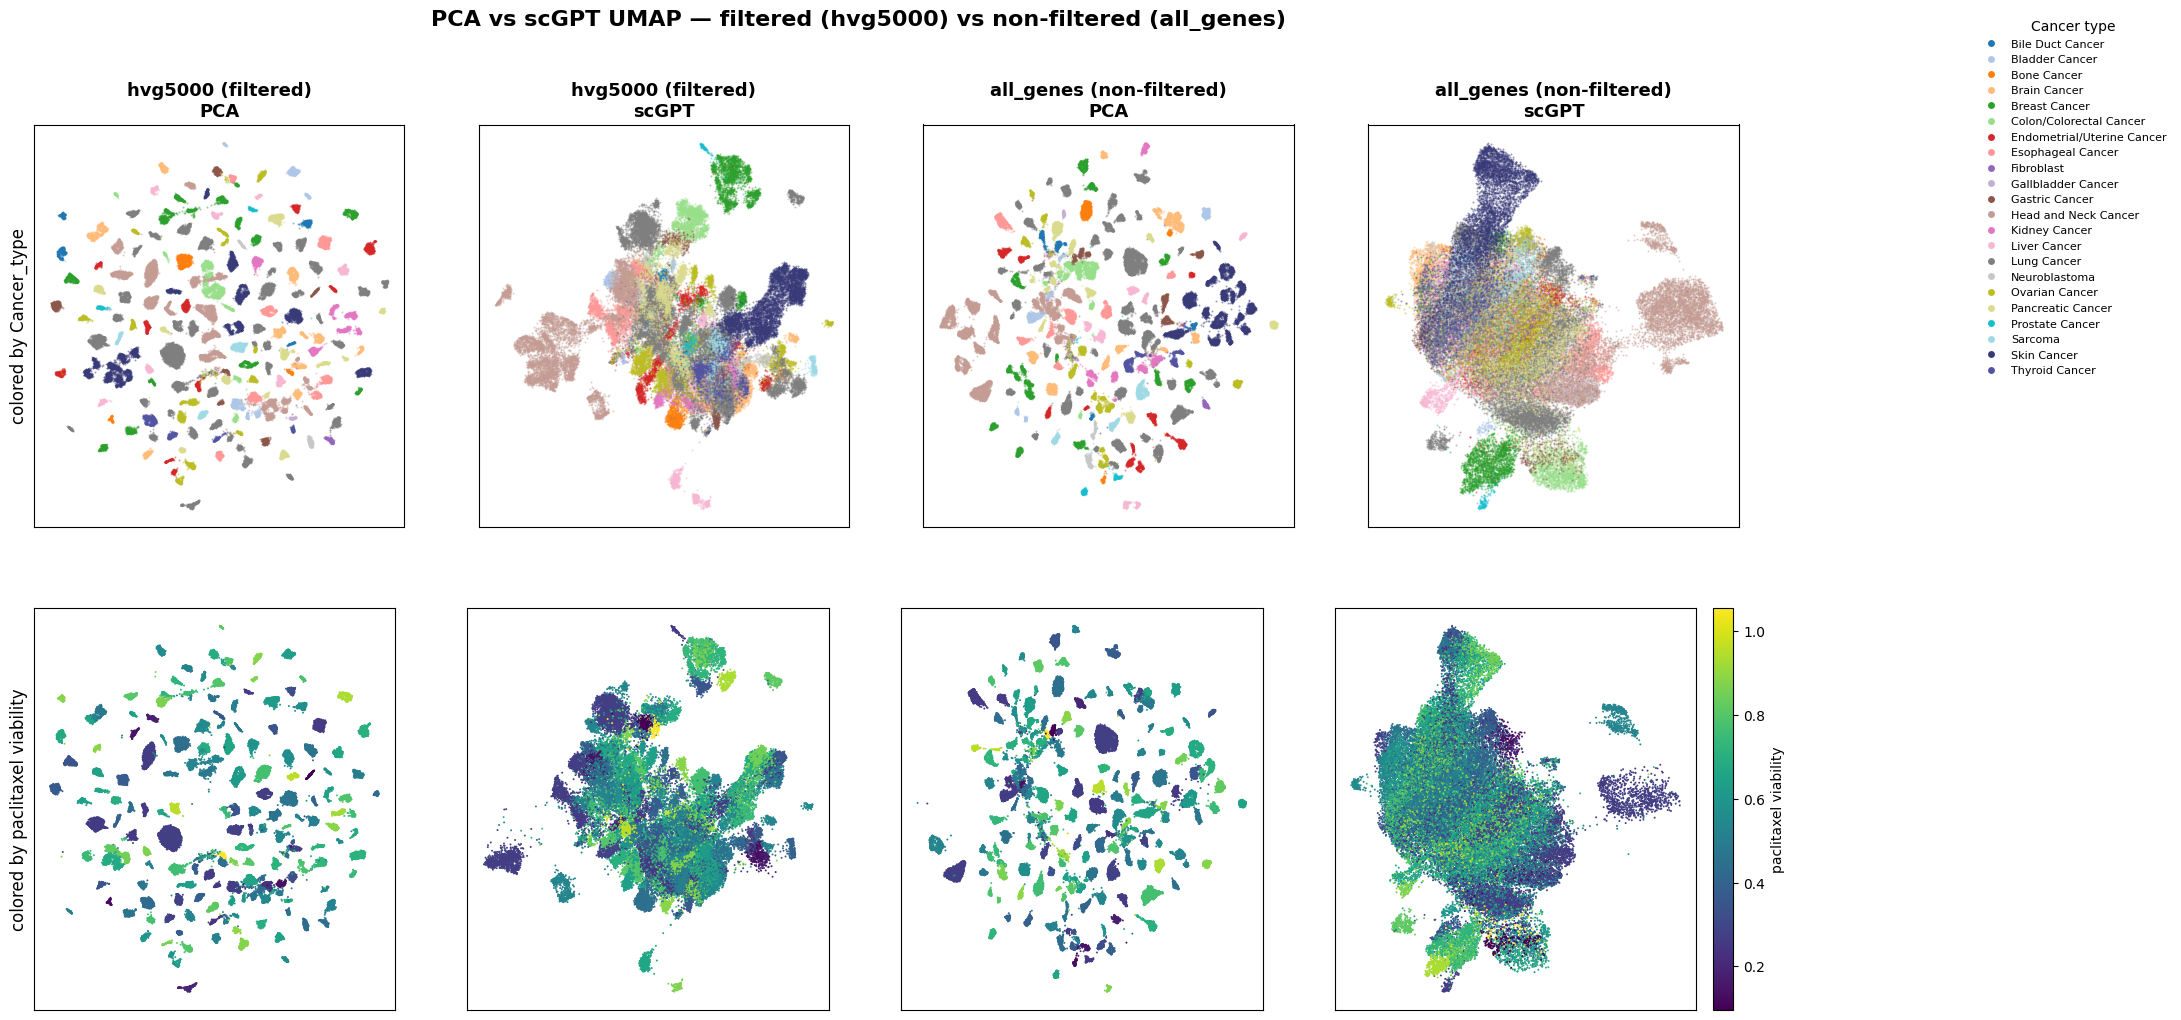

In [11]:
ref = adatas['hvg5000']
cancer = ref.obs['Cancer_type'].astype('category')
cats = list(cancer.cat.categories)
via = pd.to_numeric(ref.obs['viability_paclitaxel'], errors='coerce').to_numpy()
palette = list(plt.get_cmap('tab20').colors) + list(plt.get_cmap('tab20b').colors)
colors = {c: palette[i % len(palette)] for i, c in enumerate(cats)}

fig, axes = plt.subplots(2, 4, figsize=(22, 11.5))
sca = None
for j, (variant, rep, label) in enumerate(PANELS):
    U = umaps[(variant, rep)]
    ax = axes[0, j]
    for c in cats:
        m = cancer.values == c
        ax.scatter(U[m, 0], U[m, 1], s=2, alpha=0.5, color=colors[c], linewidths=0)
    ax.set_title(label, fontsize=13, fontweight='bold'); ax.set_xticks([]); ax.set_yticks([])
    ax = axes[1, j]
    sca = ax.scatter(U[:, 0], U[:, 1], s=2, c=via, cmap='viridis', linewidths=0)
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel('colored by Cancer_type', fontsize=12)
axes[1, 0].set_ylabel('colored by paclitaxel viability', fontsize=12)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[c], markersize=6, label=c) for c in cats]
fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.005, 0.98), fontsize=8, title='Cancer type', frameon=False)
fig.colorbar(sca, ax=list(axes[1, :]), fraction=0.015, pad=0.01, label='paclitaxel viability')
fig.suptitle('PCA vs scGPT UMAP — filtered (hvg5000) vs non-filtered (all_genes)', fontsize=16, fontweight='bold')
plt.savefig("variants.png")
plt.show()